In [1]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
import time as tm
start_time = tm.time()
init_printing(use_latex=true)
filename = "DataUse.xlsx"

In [2]:
# Choose highest degree of polynomial
k = 4

In [3]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

4

In [4]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

1461

In [5]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T
zReal[pd.isna(zReal)] = 0
zReal

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
tftReal = pd.read_excel(filename, sheet_name="TFTs").to_numpy().T   # Non-binary, contains TFT measurement.
tftReal[pd.isna(tftReal)] = 0
numTfts = np.count_nonzero(tftReal)
tftReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
dReal = np.zeros(tftReal.shape)
for r in range(len(dReal)):
    for c in range(len(dReal[0])):
        if tftReal[r,c] != 0:
            dReal[r,c] = 1

dTotal=sum(sum(dReal))
dReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
# Establish vector of expert-estimated mass flows
mEstimates = pd.read_excel(filename, sheet_name="MassFlowEstimates").to_numpy().T
mEstimates[pd.isna(mEstimates)] = 0
mEstimates

array([[29.16447097, 29.41802201, 29.44433852, ..., 37.38156896,
        36.96219626, 37.58281756],
       [60.69242432, 60.9400594 , 60.88349717, ..., 76.10930743,
        75.69367963, 75.39730625],
       [39.68307507, 39.84239784, 39.85947378, ..., 62.22377388,
        61.76020397, 62.16625229],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]])

In [9]:
# Establish vector of total mass flow at the separator over time
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal[pd.isna(MReal)] = 0
MReal

array([[129.53997035, 130.20047925, 130.18730947, ..., 175.71465026,
        174.41607986, 175.14637611]])

In [10]:
# Check for any NA values
sum(sum(pd.isna(MReal))), sum(sum(pd.isna(mEstimates))), sum(sum(pd.isna(zReal))), sum(sum(pd.isna(tftReal))), sum(sum(pd.isna(dReal)))

(0, 0, 0, 0, 0)

In [11]:
Lambda1 = 135.13 #T*n**2/dTotal
Lambda2 = 7.52
Lambda3 = 0
Lambda1, Lambda2, Lambda3

In [12]:
def runMCMC(inputs):
    MReal, tftReal, dReal, zReal, Lambda1, Lambda2, n, T, k = inputs
    
    sd=20
    
    mMCMC = tftReal + np.random.normal(0, sd, (len(tftReal), len(tftReal[0,:])))
    for i in range(len(tftReal)):
        for j in range(len(tftReal[0])):
            if tftReal[i,j]==0:
                mMCMC[i,j] = 0
   # Compile the y vector (col. vec.)
    y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
    for j in range(T):
        # fill in m values
        for i in range(n):
            y[T*i+j, 0] = np.sqrt(Lambda1) * mMCMC[i,j] 
        # fill in M values
        y[T*n+j, 0] = MReal[0,j]
    y.shape
    # Compile the A1 matrix
    A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
    for i in range(n):
        for j in range(T):
            # fill in d values
            A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
            # fill in z values
            A1[T*n+j, T*i+j] = zReal[i,j]
            # fill in forward difference formula to approximate the first order derivative
            if j > 0: # Ignore first row to not add a BC
                A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j-1] = -1 * np.sqrt(Lambda2)
                A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j] = 1 * np.sqrt(Lambda2)
            # fill in second order central difference formula to approximate the second order derivative
            if j > 1: # Ignore first two rows to not add BCs
                A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-2] = 1 * np.sqrt(Lambda3)
                A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-1] = -2 * np.sqrt(Lambda3)
                A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j] = 1 * np.sqrt(Lambda3)
    ts = np.array(list(range(T)))+1
    A2 = np.zeros([n*T, n*(k+1)])
    for block in range(n):
        for r in range(T):
            for c in range(k+1):
                A2[block*T + r, block*(k+1) + c] = ts[r]**c

    A = np.matmul(A1,A2)
    res, _, _, _ = lstsq(A, y)
    out = np.matmul(A2, res).reshape(n, T)
    return out


In [13]:
inputs = MReal, tftReal, dReal, zReal, Lambda1, Lambda2, n, T, k
N = 2000
RESULTS = np.array(np.zeros(N), dtype="object")
for iter in range(N):
    RESULTS[iter] = runMCMC(inputs)

RESULTS

array([array([[4.63904022e+01, 4.61786435e+01, 4.59678209e+01, ...,
               3.62786130e+01, 3.62196606e+01, 3.61605882e+01],
              [1.95808573e+01, 1.98867865e+01, 2.01914958e+01, ...,
               9.92204772e+01, 9.93249474e+01, 9.94294357e+01],
              [4.43640621e+01, 4.43599552e+01, 4.43560119e+01, ...,
               5.35509479e+01, 5.35887930e+01, 5.36268893e+01],
              [3.86912576e-14, 7.70753882e-14, 1.15153423e-13, ...,
               1.05828593e-13, 7.24033623e-14, 3.86912490e-14]])   ,
       array([[ 1.47487097e+01,  1.48921652e+01,  1.50347639e+01, ...,
                2.49926698e+01,  2.47082138e+01,  2.44222605e+01],
              [ 7.70377672e+01,  7.68686969e+01,  7.67014153e+01, ...,
                1.30177429e+02,  1.30901942e+02,  1.31630236e+02],
              [ 2.14899944e+01,  2.19306897e+01,  2.23682631e+01, ...,
                2.68795539e+01,  2.63691319e+01,  2.58552626e+01],
              [-3.84592075e-14, -7.66150105e-14, -1.1

In [18]:
# Find Percentiles
MEAN = np.mean(RESULTS)
UP = np.zeros((len(MEAN), len(MEAN[0])))
DOWN = np.zeros((len(MEAN), len(MEAN[0])))
#SD = np.std(RESULTS)
#UP = MEAN + 1.96* SD / np.sqrt(N)
#DOWN = MEAN - 1.96* SD / np.sqrt(N)
for i in range(n):
    for t in range(T):
        Rsorted = []
        for r in RESULTS:
            Rsorted.append(r[i,t])
        DOWN[i,t] = np.percentile(Rsorted, 25)
        UP[i,t] = np.percentile(Rsorted, 75)
    

UP.shape

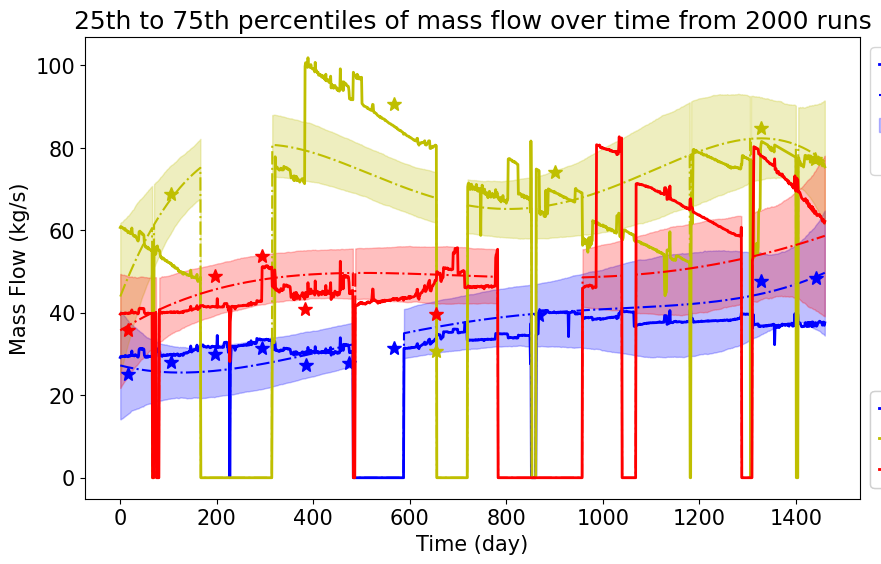

In [19]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k', 'm']
lines=[]
for i in range(n-1):
    l1, = plt.plot(range(T),mEstimates[i,:][:], colours[i]+'-', lw=2, label="Expert-Estimated flow for well "+str(i))
    
    # Plot Means
    l2, = plt.plot(range(T),MEAN[i,:] * zReal[i,:], colours[i]+'-.', lw=1.5, label="Mean predicted flow for well "+str(i))
    # Plot Confidence Intervals
    l3 = plt.fill_between(np.array(range(T)), DOWN[i,:] * zReal[i,:], UP[i,:] * zReal[i,:], color=colours[i], alpha=0.25, label="25th to 75th Percentiles for well "+str(i))
    
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(tftReal[i,:]):
        if element != 0:
            monthplot.append(month)
            tftplot.append(tftReal[i,month])
    l4, = plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="Unperturbed TFT measurements for well "+str(i))
            
    lines.append([l1,l2,l3,l4])

plt.title("25th to 75th percentiles of mass flow over time from 2000 runs")
plt.xlabel("Time (day)")
plt.ylabel("Mass Flow (kg/s)")

legend1 = plt.legend(lines[0], ["Expert's Estimate", "LLSO Model's Mean Estimate", "25th to 75th Percentile of LLSO estimates", "TFT Point Provided"], bbox_to_anchor=(1., 1.0), loc='upper left')
legend2 = plt.legend([l[0] for l in lines], ["Well 1", "Well 2", "Well 3", "Well 4", "Well 5"], bbox_to_anchor=(1.0, 0.0), loc='lower left')

plt.gca().add_artist(legend1)
plt.gca().add_artist(legend2)
plt.rcParams['font.size'] = 15

plt.savefig("MCRealData.svg", bbox_inches='tight', pad_inches=5)


In [43]:
# Plot total flow vs found total flow
plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Expert-Estimated Total Mass Flow")
plt.plot(range(T), sum(MEAN * zReal), 'b-.', lw=1.5, label="Mean predicted flow for well "+str(i))

plt.title("Estimated and real total mass flows over time, with NEW solving method")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()

NameError: name 'times' is not defined

Bayesian model based on normal distribution of provided data. Bishop book